In [14]:
from Bio import SeqIO
from collections import Counter
import pandas as pd 
import re
import requests
import json
import time
import glob
import pprint
import seaborn as sns

from matplotlib.ticker import MaxNLocator
from matplotlib.colors import ListedColormap
import pycountry 
import pycountry_convert as pc
pp = pprint.PrettyPrinter()
import numpy as np
from tabulate import tabulate
import geopandas as gpd
from geopandas import GeoDataFrame
import matplotlib.pyplot as plt
from matplotlib import cm
from shapely.geometry import Point, Polygon
import regex as re
import plotly.graph_objects as go
import os

import plotly.express as px

import scipy.stats
import statsmodels.formula.api as smf
#import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split
import pandas.plotting as pd_plot
# Use tab20 colormap to manually select colors
colormap = cm.get_cmap('tab20')

%set_env folder = \\share.univie.ac.at\envpol\11_research platform_DIGIGOV\Paul\dsi_origins\

env: folder=\\share.univie.ac.at\envpol\11_research platform_DIGIGOV\Paul\dsi_origins\


C:\Users\a494-nipw010\AppData\Local\Temp\ipykernel_13488\2417737306.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab20')


In [16]:
path = %env folder

In [18]:
df = pd.read_csv(path+r'\processed_data\resubmission_analysis.csv', index_col = 0)

C:\Users\a494-nipw010\AppData\Local\Temp\ipykernel_13488\1384640488.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path+r'\processed_data\resubmission_analysis.csv', index_col = 0)


In [3]:
df_raw = pd.read_csv(path+R'processed_data\extractivism_com3_type_time_iucn.csv', index_col = 0,dtype={'id_select': 'str'})

### 1. prepare data

In [8]:
df = df_raw.copy().astype({'community':'str', 'marine':'int', 'crops': 'int', 'pathogens':'int'}).set_index(['id_select']).rename(columns = {'Viruses':'viruses', 'Eukaryota':'eukaryota', 'Bacteria':'bacteria', 'Archaea':'archaea'})

In [10]:
#dichotomize semantic categories
df = df.join(pd.get_dummies(df['community'], dtype=float,prefix='community')).drop(columns = ['community']).rename(columns = { 'community_0.0':'public_health','community_1.0':'biotechnology', 'community_2.0':'basic_research','iucn_cat_binary': 'iucn_threatened'}) 

In [11]:
#construct general extractivism variable
no_local_authors = list(df.index[(df['extractivism_g77_oecd_2'] == 1) | 
        (df['extractivism_g77_brics_2'] == 1) | 
        (df['extractivism_brics_oecd_2'] == 1) | 
        (df['extractivism_brics_g77_2'] == 1) | 
        (df['extractivism_oecd_brics_2'] == 1) | 
        (df['extractivism_oecd_g77_2'] == 1)])

any_int_sourcing = list(df.index[(df['g77_oecd'] == 1) | 
        (df['g77_brics'] == 1) | 
        (df['oecd_brics'] == 1) | 
        (df['oecd_g77'] == 1) | 
        (df['brics_g77'] == 1) | 
        (df['brics_oecd'] == 1)])


In [13]:
extractivism_2 = []
sourcing = []
for id_select in df.index.tolist():
    source = np.nan
    extract = np.nan
    
    if id_select in any_sourcing:
        source = 1
        if id_select in any_extract_2: 
            extract = 1
        else:
            extract = 0
    else:
        source = 0

    sourcing.append(source)
    extractivism_2.append(extract)

df['extractivism_2'] = extractivism_2
df['sourcing_foreign'] = sourcing


In [12]:
df = pd.read_csv(path+r'\processed_data\resubmission_analysis.csv', index_col = 0)

FileNotFoundError: [Errno 2] No such file or directory: 'X:\\5_Research\\Paul\\dsi_origins\\\\processed_data\\resubmission_analysis.csv'

In [28]:
df_vis = df.rename(columns = {'no_local_authors': 'International DSI sourcing: Without local authors',
                              'foreign_lead': 'International DSI sourcing: Foreign lead authors',
                            'sourcing_international': 'International DSI sourcing',
                              'sourcing_domestic': 'Domestic DSI sourcing',
                              'local_lead': 'International DSI sourcing: At least one local lead author',
                    'extractivism_g77_oecd_1':'G77 -> OECD extractivism 1', 
                   'extractivism_g77_brics_1':'G77 -> BRICS extractivism 1',
                   'extractivism_oecd_brics_1':'OECD -> BRICS extractivism 1',
                   'extractivism_oecd_g77_1':'OECD -> G77 extractivism 1', 
                   'extractivism_brics_g77_1': 'BRICS -> G77 extractivism 1',
                    'extractivism_brics_oecd_1': 'BRICS -> OECD extractivism 1',
                    'extractivism_g77_oecd_2':'G77 -> OECD extractivism 2', 
                   'extractivism_g77_brics_2':'G77 -> BRICS extractivism 2',
                   'extractivism_oecd_brics_2':'OECD -> BRICS extractivism 2',
                   'extractivism_oecd_g77_2':'OECD -> G77 extractivism 2', 
                   'extractivism_brics_g77_2': 'BRICS -> G77 extractivism 2',
                    'extractivism_brics_oecd_2': 'BRICS -> OECD extractivism 2',
                     'g77_oecd': 'G77 -> OECD',
                       'g77_brics': 'G77 -> BRICS', 
                        'oecd_brics': 'OECD -> BRICS', 
                        'oecd_g77': 'OECD -> G77', 
                        'brics_g77': 'BRICS -> G77', 
                        'brics_oecd': 'BRICS -> OECD',
                              
                    'public_health':'Public health',
                   'biotechnology':'Biotechnology', 
                   'basic_research':'Basic research', 
                   'iucn_threatened': 'IUCN threatened species',
                   'eukaryota':'Eukaryota',
 'bacteria':'Bacteria',
 'archaea':'Archaea',
 'viruses':'Viruses',
 'marine':'Marine',
 'pathogens': 'Pathogens',
 'crops':'Crops',
 'year_published':'Publication year',
 'after_nagoya':'After Nagoya',
 'megadiv':'Megabiodiverse',
    'megadiv_brics':'Megabiodiverse (BRICS)',
    'megadiv_g77':'Megabiodiverse (G77)'
    
                              
                             })

### 2. Bivariate relationships

In [52]:
df_vis_bars = df_vis.drop(columns=['Publication year', 'G77 -> OECD extractivism 1',
                                                                      'G77 -> BRICS extractivism 1',
                                                                      'OECD -> BRICS extractivism 1',
                                                                      'OECD -> G77 extractivism 1',
                                                                      'BRICS -> G77 extractivism 1',
                                                                      'BRICS -> OECD extractivism 1',
                                                                      'G77 -> OECD extractivism 2',
                                                                      'G77 -> BRICS extractivism 2',
                                                                      'OECD -> BRICS extractivism 2',
                                                                      'OECD -> G77 extractivism 2',
                                                                      'BRICS -> G77 extractivism 2',
                                                                      'BRICS -> OECD extractivism 2',
                                                                     'Crops', 'After Nagoya', 'Megabiodiverse (G77)', 'Megabiodiverse (BRICS)']).groupby('International DSI sourcing').sum().transpose().rename(columns = {0:'Domestic', 1:'International'})
df_vis_extr_2 = df_vis.drop(columns=['Publication year', 'G77 -> OECD extractivism 1',
                                                                      'G77 -> BRICS extractivism 1',
                                                                      'OECD -> BRICS extractivism 1',
                                                                      'OECD -> G77 extractivism 1',
                                                                      'BRICS -> G77 extractivism 1',
                                                                      'BRICS -> OECD extractivism 1',
                                                                      'G77 -> OECD extractivism 2',
                                                                      'G77 -> BRICS extractivism 2',
                                                                      'OECD -> BRICS extractivism 2',
                                                                      'OECD -> G77 extractivism 2',
                                                                      'BRICS -> G77 extractivism 2',
                                                                      'BRICS -> OECD extractivism 2',
                                                                     'Crops', 'After Nagoya', 'Megabiodiverse (G77)', 'Megabiodiverse (BRICS)']).groupby('International DSI sourcing').sum().transpose().rename(columns = {0:'Collaborative', 1:'Without local authors'})

df_vis_bars['Without local authors'] = df_vis_extr_2['Without local authors'] 

In [56]:

df_vis_bars

International DSI sourcing,Domestic,International,Without local authors
G77 -> OECD,0.0,18870.0,8631.0
G77 -> BRICS,0.0,3619.0,799.0
OECD -> BRICS,0.0,4175.0,893.0
OECD -> G77,0.0,2993.0,261.0
BRICS -> G77,0.0,2232.0,256.0
BRICS -> OECD,0.0,12861.0,4929.0
other_g77_oecd,0.0,4837.0,0.0
other_g77_brics,0.0,1587.0,0.0
other_oecd_brics,0.0,2565.0,0.0
other_oecd_g77,0.0,2454.0,0.0


In [58]:
# Load the dictionary from the JSON file
with open(path+R"processed_data/edge_colors_extr1.json", "r") as file:
    edge_colors_extr1_json = json.load(file)

# Convert string keys back to tuples
edge_colors_extr1 = {eval(key): value for key, value in edge_colors_extr1_json.items()}

# Load the dictionary from the JSON file
with open(path+R"processed_data/edge_colors_extr2.json", "r") as file:
    edge_colors_extr2_json = json.load(file)

# Convert string keys back to tuples
edge_colors_extr2 = {eval(key): value for key, value in edge_colors_extr2_json.items()}


C:\Users\a494-nipw010\AppData\Local\Temp\ipykernel_13488\552264534.py:63: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_blues = cm.get_cmap('Blues')


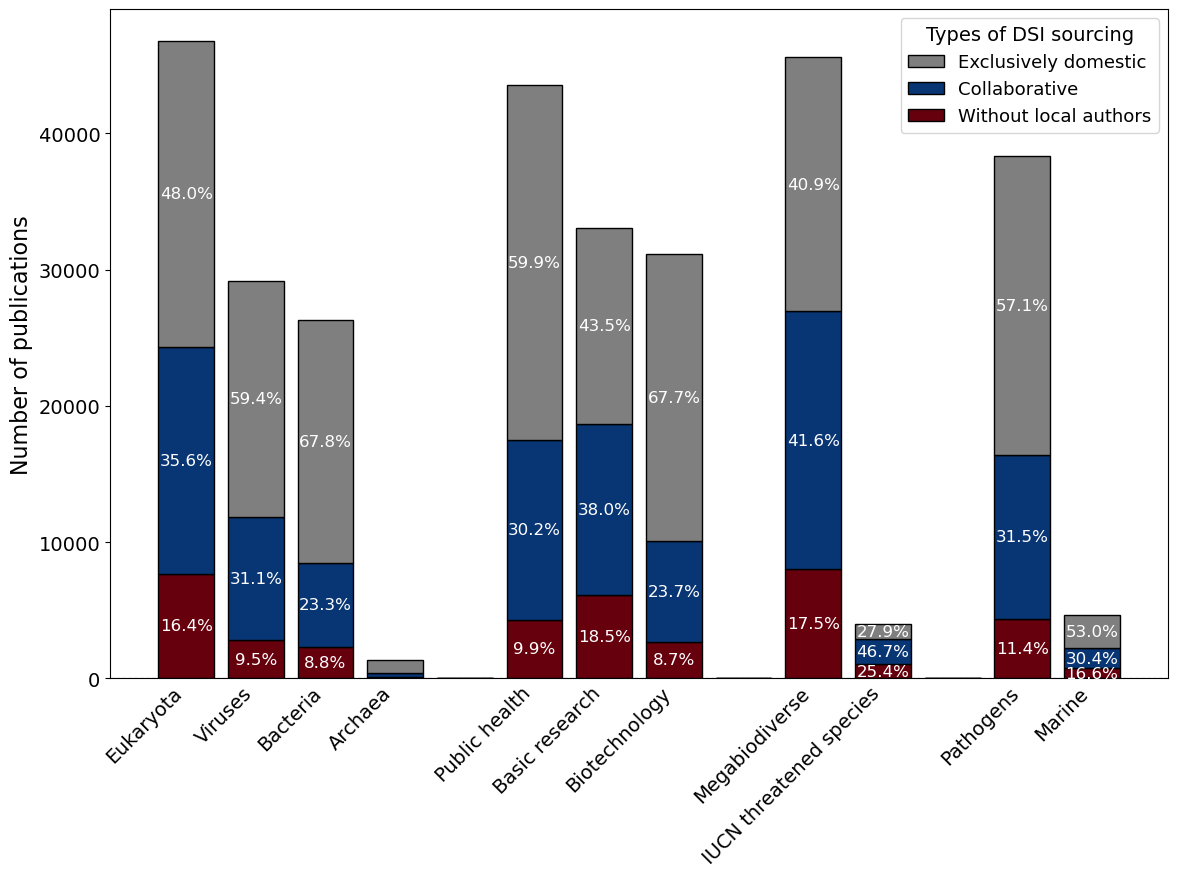

In [60]:
import matplotlib.pyplot as plt

# Assuming df_vis_bars is already computed
# Extract predictors and their corresponding changes for three values
predictors = list(df_vis_bars.index)
publications = list(df_vis_bars['Domestic'])
foreign_sourced = list(df_vis_bars['International'])
extractivist = list(df_vis_bars['Without local authors'])

# Combine into a single structure
data = list(zip(predictors, publications, foreign_sourced, extractivist))

# Define groupings
groups = {
    "Taxonomic groups": ["Eukaryota", "Viruses", "Bacteria", "Archaea"],
    "Research types": ["Basic research", "Biotechnology", "Public health"],
    "Socio-ecological context": ["Megabiodiverse", "IUCN threatened species"],
    "Regulatory context": ["Marine", "Pathogens"]
}

# Sort within each group based on total publications
sorted_groups = {}
for group_name, group_predictors in groups.items():
    group_data = [item for item in data if item[0] in group_predictors]
    group_data.sort(key=lambda x: x[1] + x[2] + x[3], reverse=True)  # Sort by total publications
    sorted_groups[group_name] = group_data

# Flatten the list of predictors by sorted groups and add spaces for visual separation
grouped_predictors = []
adjusted_publications = []
adjusted_foreign_sourced = []
adjusted_extractivist = []

for group_name, group_data in sorted_groups.items():
    for predictor, pub_val, foreign_val, extr_val in group_data:
        grouped_predictors.append(predictor)
        adjusted_publications.append(pub_val)
        adjusted_foreign_sourced.append(foreign_val)
        adjusted_extractivist.append(extr_val)
    grouped_predictors.append("")  # Add a blank space for visual separation
    adjusted_publications.append(0)
    adjusted_foreign_sourced.append(0)
    adjusted_extractivist.append(0)


# Remove the last blank space
grouped_predictors = grouped_predictors[:-1]
adjusted_publications = adjusted_publications[:-1]
adjusted_foreign_sourced = adjusted_foreign_sourced[:-1]
adjusted_extractivist = adjusted_extractivist[:-1]

# Define a threshold for suppressing labels
label_threshold = 2000  # Suppress labels if total publications (sums + counts) are below this value


# Set font size for the entire plot
plt.rcParams.update({'font.size': 14})

# Define colors for the stacked bar plot

# Fetch the color for a specific edge
color_g77_oecd_extr2 = edge_colors_extr2.get(('G77', 'OECD', 0), colormap(0))
cmap_blues = cm.get_cmap('Blues')
color_sourcing = cmap_blues(250)

affected_color = color_g77_oecd_extr2
# Use the specific color for affected bars
unaffected_color = color_sourcing  # Use tab20 color for unaffected bars
domestic_color = colormap(14)

# Create a stacked bar plot
plt.figure(figsize=(12, 9))

# Plot stacked bars
bars1 = plt.bar(
    range(len(grouped_predictors)),
    adjusted_extractivist,
    color=affected_color,  # Use the specific color
    label='Without local authors',
    edgecolor='black',
)
bars2 = plt.bar(
    range(len(grouped_predictors)),
    adjusted_foreign_sourced,
    bottom=adjusted_extractivist,
    color=unaffected_color,  # Grey for unaffected
    label='International',
    edgecolor='black',
)
bars3 = plt.bar(
    range(len(grouped_predictors)),
    adjusted_publications,
    bottom=[sum(x) for x in zip(adjusted_extractivist, adjusted_foreign_sourced)],
    color=domestic_color,
    label='Exclusively domestic',
    edgecolor='black',
)

# Add labels and percentages to the stacks
for i, (bar1, bar2, bar3, extr_val, foreign_val, pub_val) in enumerate(zip(bars1, bars2, bars3, adjusted_extractivist, adjusted_foreign_sourced, adjusted_publications)):
    if grouped_predictors[i] != "":  # Skip dummy spaces
        total = pub_val + foreign_val + extr_val
        if total > label_threshold:  # Add labels only if total is above threshold
            plt.text(bar1.get_x() + bar1.get_width() / 2, bar1.get_height() / 2, f'{extr_val/total*100:.1f}%', 
                     ha='center', va='center', fontsize=12, color='white')
            plt.text(bar2.get_x() + bar2.get_width() / 2, bar2.get_y() + bar2.get_height() / 2, f'{foreign_val/total*100:.1f}%', 
                     ha='center', va='center', fontsize=12, color='white')
            plt.text(bar3.get_x() + bar3.get_width() / 2, bar3.get_y() + bar3.get_height() / 2, f'{pub_val/total*100:.1f}%', 
                     ha='center', va='center', fontsize=12, color='white')

# Add labels and title
plt.ylabel('Number of publications', fontsize=16)
plt.xticks(range(len(grouped_predictors)), grouped_predictors, rotation=45, ha='right')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax = plt.gca()  # Get the current axis
ax.set_xticks(range(len(grouped_predictors)))  # Set all ticks
ax.tick_params(axis="x", which="both", length=0)  # Hide tick marks

# Add legend with title and reordered entries
plt.legend(
    handles=[bars3, bars2, bars1],  # Changing the order
    labels=['Exclusively domestic', 'Collaborative', 'Without local authors'],  # Matching new order
    title="Types of DSI sourcing",  # Adding a title to the legend
    fontsize=13
)

# Adjust layout and show plot
plt.tight_layout()
plt.savefig(path + R"plots/barplot_new.png", dpi=300, bbox_inches="tight")
plt.savefig(path + R"plots/barplot_new.svg", dpi=300, bbox_inches="tight") 
plt.show()


In [62]:
df_vis.columns

Index(['G77 -> OECD extractivism 1', 'G77 -> BRICS extractivism 1',
       'OECD -> BRICS extractivism 1', 'OECD -> G77 extractivism 1',
       'BRICS -> G77 extractivism 1', 'BRICS -> OECD extractivism 1',
       'G77 -> OECD extractivism 2', 'G77 -> BRICS extractivism 2',
       'OECD -> BRICS extractivism 2', 'OECD -> G77 extractivism 2',
       'BRICS -> G77 extractivism 2', 'BRICS -> OECD extractivism 2',
       'G77 -> OECD', 'G77 -> BRICS', 'OECD -> BRICS', 'OECD -> G77',
       'BRICS -> G77', 'BRICS -> OECD', 'other_g77_oecd', 'other_g77_brics',
       'other_oecd_brics', 'other_oecd_g77', 'other_brics_g77',
       'other_brics_oecd', 'Eukaryota', 'Bacteria', 'Archaea', 'Viruses',
       'Marine', 'Pathogens', 'Crops', 'Publication year', 'After Nagoya',
       'Megabiodiverse', 'Megabiodiverse (G77)', 'Megabiodiverse (BRICS)',
       'IUCN threatened species', 'Public health', 'Biotechnology',
       'Basic research', 'International DSI sourcing: Foreign lead authors',
      

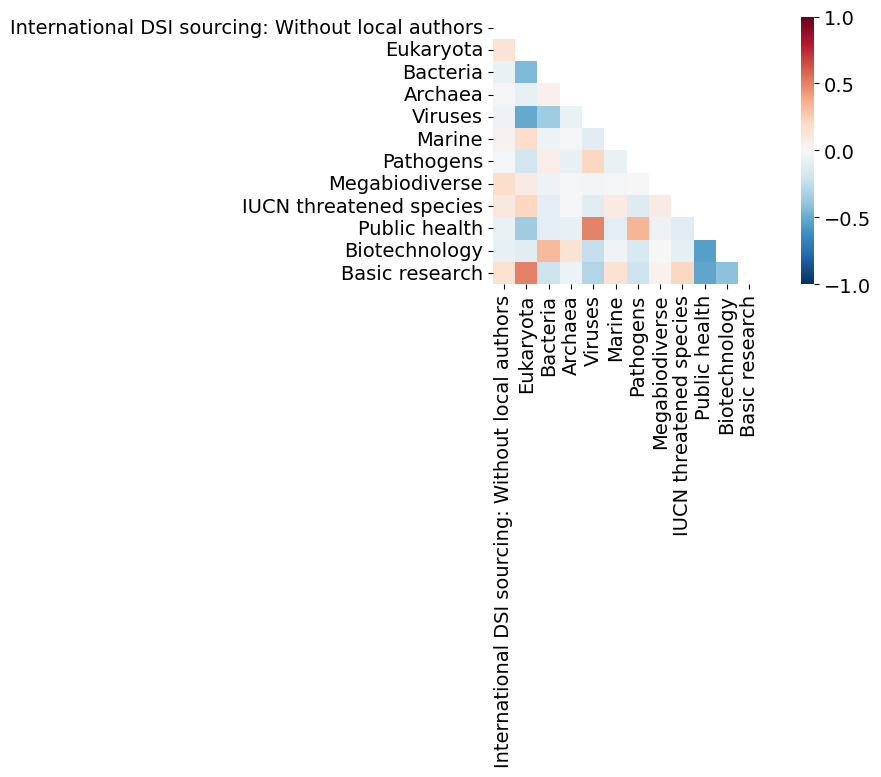

In [66]:
#heatmap
corr = df_vis.drop(columns = ['Publication year', 'After Nagoya', 'Crops',  
                              'BRICS -> OECD extractivism 2', 'G77 -> OECD extractivism 2', 
                              'G77 -> BRICS extractivism 2', 'BRICS -> OECD extractivism 1', 
                              'G77 -> OECD extractivism 1', 'G77 -> BRICS extractivism 1', 
                              'OECD -> G77 extractivism 1', 'OECD -> G77 extractivism 2', 
                              'BRICS -> G77 extractivism 1',  'BRICS -> G77 extractivism 2', 
                              'OECD -> BRICS extractivism 1', 'OECD -> BRICS extractivism 2', 
                              'Megabiodiverse (BRICS)', 'Megabiodiverse (G77)'])[['International DSI sourcing: Without local authors','Eukaryota', 'Bacteria', 'Archaea', 'Viruses', 'Marine', 'Pathogens',
       'Megabiodiverse',
       'IUCN threatened species', 'Public health', 'Biotechnology',
       'Basic research']].corr()

mask = np.zeros_like(corr, dtype='bool')
mask[np.triu_indices_from(mask)] = True

plt.figure(figsize=(12, 8))
# Set font size for the entire plot
plt.rcParams.update({'font.size': 14})



plt.grid(False)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, square=True,linewidths=0,cmap="RdBu_r",vmin=-1,vmax=1)

plt.tight_layout()
plt.savefig(path+R"plots/correlation_matrix_new.pdf")
plt.savefig(path+R"plots/correlation_matrix_new.png")
plt.show()